# MURA X-Ray Classification

**Institution:** Athens University of Economics and Business (AUEB)

**Author:** Michail Theofanopoulos p3352401

---

## What are we doing?

We have X-ray images of bones (shoulder, elbow, wrist, hand, finger, forearm, humerus) and we want to automatically decide if each image is **normal** or **abnormal**.

This is a **binary classification** problem. The model outputs a number between 0 and 1:
- Close to **0** → the model thinks the X-ray is **normal**
- Close to **1** → the model thinks the X-ray is **abnormal**

## Dataset: MURA

MURA (MUsculoskeletal RAdiographs) was created by Stanford University.
- ~40,000 X-ray images across 7 body parts
- Already split into **train** (~36,800 images) and **validation** (~3,200 images)
- Each image is labeled by a radiologist as normal or abnormal

## Models we will train in this notebook

| # | Model | Type |
|---|---|---|
| 1 | Custom CNN | Built from scratch |
| 2 | DenseNet121 | Pre-trained on ImageNet, fine-tuned |

---
## Step 1 - Download the Dataset

In [1]:
import os

# ---------------------------------------------------------------
# On Kaggle: add the MURA dataset via the Data tab (search "MURA v1.1"),
# then confirm the path below matches what appears in the file browser.
# ---------------------------------------------------------------
DATASET_PATH = '/kaggle/input/datasets/cjinny/mura-v11'

# Verify structure — MURA-v1.1 folder must be present
print('Dataset path exists:', os.path.exists(DATASET_PATH))
print('Contents:', os.listdir(DATASET_PATH) if os.path.exists(DATASET_PATH) else 'NOT FOUND')

# ---------------------------------------------------------------
# Original Colab/Google Drive download — not needed on Kaggle
# ---------------------------------------------------------------
# import gdown
# GDRIVE_FILE_ID = '1GW1j9e2KlAZ7fCztft7ubdBRHRvhfPDm'
# if not os.path.exists(f'{DATASET_PATH}/MURA-v1.1'):
#     os.makedirs(DATASET_PATH, exist_ok=True)
#     zip_path = f'{DATASET_PATH}/mura-v11.zip'
#     print('Downloading dataset from Google Drive ...')
#     gdown.download(f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}', zip_path, quiet=False)
#     print('Unzipping ...')
#     os.system(f'unzip -q {zip_path} -d {DATASET_PATH}')
#     os.remove(zip_path)
#     print('Done!')
# else:
#     print('Dataset already extracted, skipping download.')

Dataset path exists: True
Contents: ['MURA-v1.1']


### GPU & Mixed Precision Setup

We enable **mixed_float16** precision to speed up training on the GPU. This uses 16-bit floats for most operations and 32-bit where needed, cutting memory usage roughly in half.

In [2]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

print(tf.config.list_physical_devices('GPU'))
mixed_precision.set_global_policy('mixed_float16')

2026-03-11 07:23:22.291619: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773213802.452386      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773213802.496869      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773213802.882137      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773213802.882190      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773213802.882192      55 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Step 2 - Imports & Configuration

In [15]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import backend as K, mixed_precision
from tensorflow.keras.applications import DenseNet121, EfficientNetB0
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import (Input, Conv2D, Dense, Dropout, MaxPool2D,
                                      BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, accuracy_score, f1_score)

mixed_precision.set_global_policy('mixed_float16')

%matplotlib inline

IMG_SIZE   = 224   # resize all images to 224x224 pixels
BATCH_SIZE = 64    # number of images processed at once
EPOCHS     = 30    # maximum training epochs (EarlyStopping will stop earlier)

print('TensorFlow version:', tf.__version__)
print('Mixed precision policy:', mixed_precision.global_policy().name)

TensorFlow version: 2.19.0
Mixed precision policy: mixed_float16


---
## Step 3 - Load the Data

The MURA dataset comes with CSV files listing every image path and its label.
We read those CSVs and build a single DataFrame with columns: `image_path`, `label_type`, `set_type`, `category`.

In [4]:
def extract_set_category(path):
    pattern = r'.*(?P<set_type>train|valid)/(?P<category>XR_[A-Z]+)/(?P<patient_id>patient\d+)/study.*'
    match = re.match(pattern, path)
    return match.groupdict() if match else None


def load_split(split, dataset_path=DATASET_PATH):
    image_paths = pd.read_csv(f'{dataset_path}/MURA-v1.1/{split}_image_paths.csv',
                              header=None, names=['image_path'])
    image_paths['path'] = image_paths['image_path'].apply(
        lambda x: '/'.join(x.split('/')[:-1]) + '/'
    )
    labels = pd.read_csv(f'{dataset_path}/MURA-v1.1/{split}_labeled_studies.csv',
                         header=None, names=['path', 'label'])
    return labels.merge(image_paths, on='path', how='left')


df = pd.concat([load_split('train'), load_split('valid')]).reset_index(drop=True)
df = pd.concat([df, pd.DataFrame(df['path'].apply(extract_set_category).tolist())], axis=1)
df['label_type'] = df['label'].map({1: 'abnormal', 0: 'normal'})
df['image_path'] = df['image_path'].apply(lambda x: os.path.join(DATASET_PATH, x))

print(f'Total images: {len(df)}')
print(f'Train: {len(df[df["set_type"]=="train"])}  |  Validation: {len(df[df["set_type"]=="valid"])}')
df.head()

Total images: 40005
Train: 36808  |  Validation: 3197


,path,label,image_path,set_type,category,patient_id,label_type
0,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,1,/kaggle/input/datasets/cjinny/mura-v11/MURA-v1...,train,XR_SHOULDER,patient00001,abnormal
1,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,1,/kaggle/input/datasets/cjinny/mura-v11/MURA-v1...,train,XR_SHOULDER,patient00001,abnormal
2,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,1,/kaggle/input/datasets/cjinny/mura-v11/MURA-v1...,train,XR_SHOULDER,patient00001,abnormal
3,MURA-v1.1/train/XR_SHOULDER/patient00002/study...,1,/kaggle/input/datasets/cjinny/mura-v11/MURA-v1...,train,XR_SHOULDER,patient00002,abnormal
4,MURA-v1.1/train/XR_SHOULDER/patient00002/study...,1,/kaggle/input/datasets/cjinny/mura-v11/MURA-v1...,train,XR_SHOULDER,patient00002,abnormal


---
## Step 4 - Explore the Dataset

In [5]:
print('Label distribution:')
print(df['label_type'].value_counts())
print()
print('Images per body part:')
print(df.groupby(['category', 'label_type']).size().unstack(fill_value=0))

Label distribution:
label_type
normal      23602
abnormal    16403
Name: count, dtype: int64

Images per body part:
label_type   abnormal  normal
category                     
XR_ELBOW         2236    3160
XR_FINGER        2215    3352
XR_FOREARM        812    1314
XR_HAND          1673    4330
XR_HUMERUS        739     821
XR_SHOULDER      4446    4496
XR_WRIST         4282    6129


> **Important:** There are more normal images (~23,600) than abnormal (~16,400). This **class imbalance** means a naive model could get ~60% accuracy just by always predicting 'normal'. We fix this with **class weights** - the model is penalised more heavily for mistakes on the minority class.

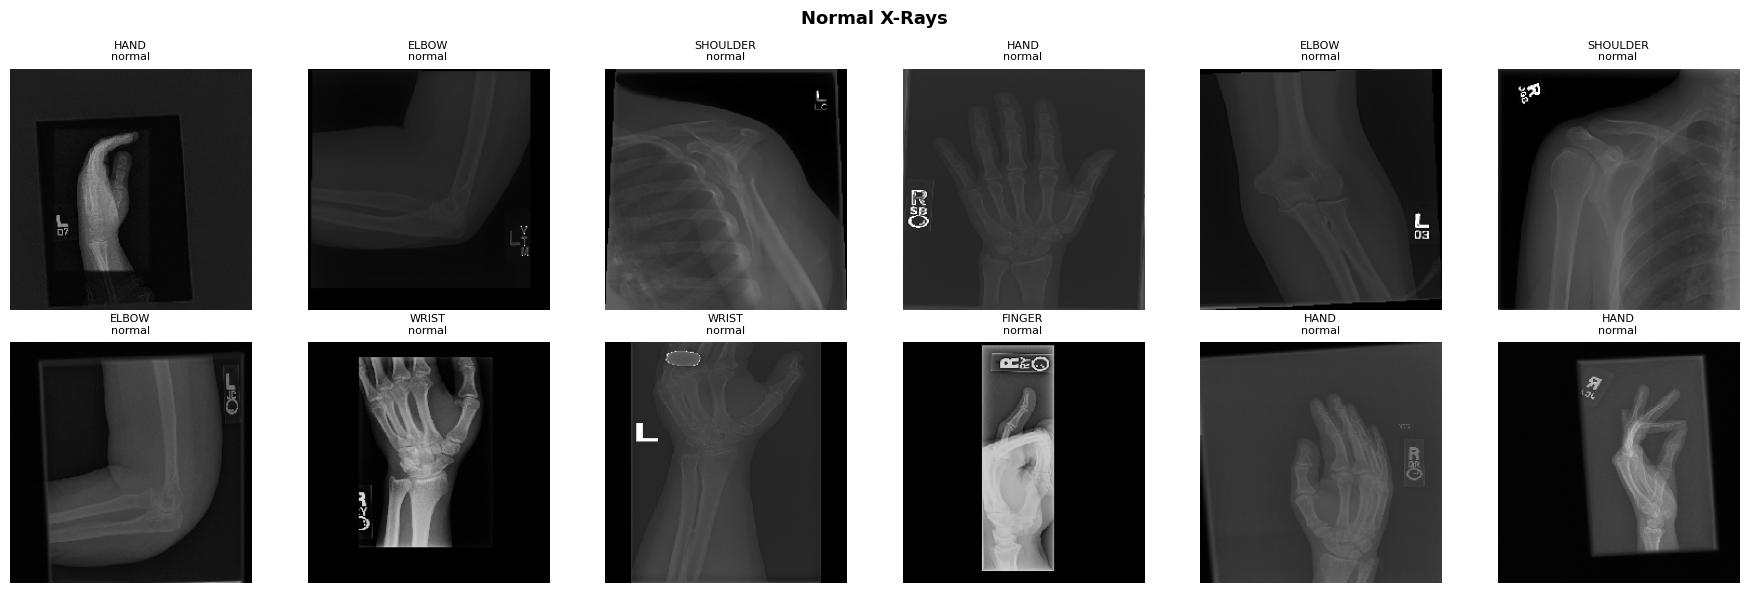

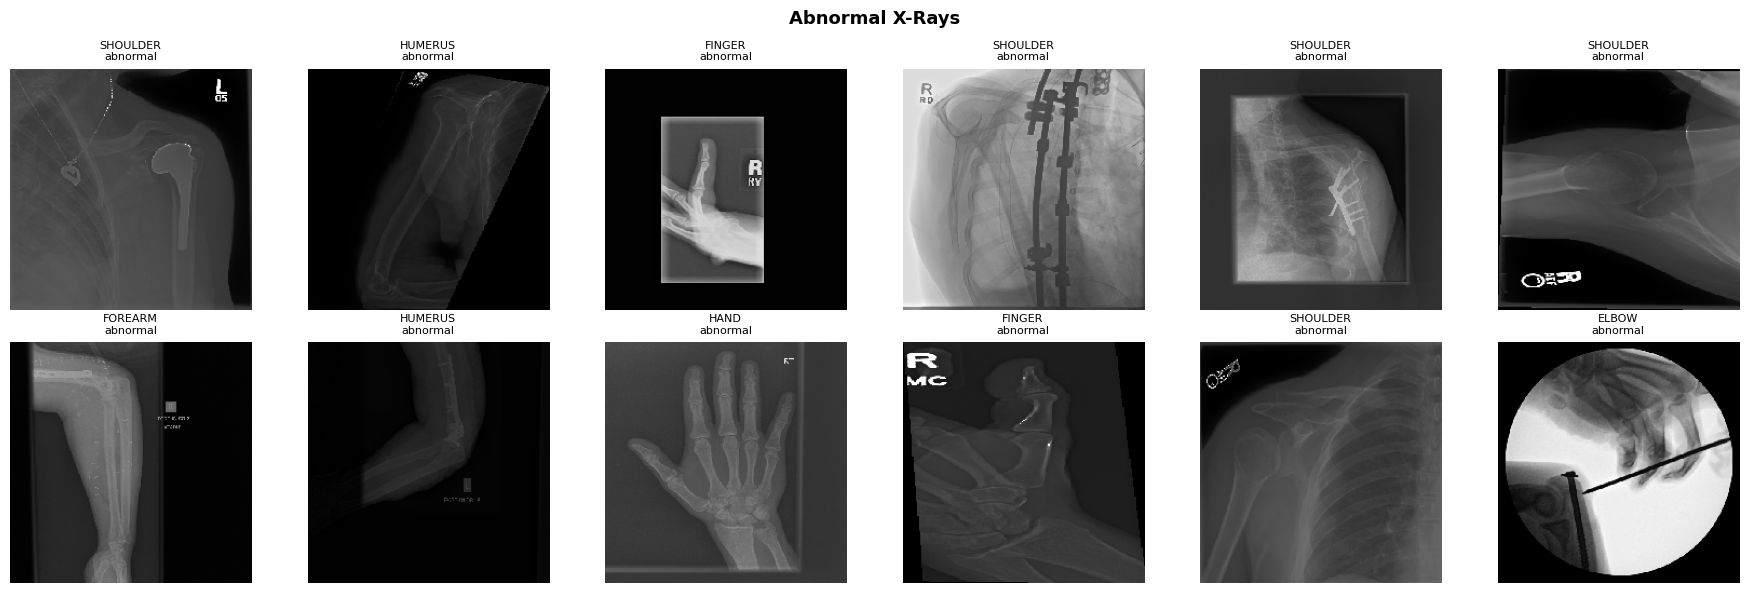

In [6]:
def show_samples(dataframe, title=''):
    sample = dataframe.sample(12, random_state=42)
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for ax, (_, row) in zip(axes.flat, sample.iterrows()):
        img = load_img(row['image_path'], target_size=(IMG_SIZE, IMG_SIZE))
        ax.imshow(img)
        ax.set_title(f"{row['category'].replace('XR_', '')}\n{row['label_type']}", fontsize=8)
        ax.axis('off')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(df[df['label_type'] == 'normal'],   title='Normal X-Rays')
show_samples(df[df['label_type'] == 'abnormal'], title='Abnormal X-Rays')

---
## Step 5 - Data Generators

We use Keras `ImageDataGenerator` to:
- Load images from disk in batches (avoids loading 40k images into RAM at once)
- Apply **data augmentation** on training images (random flips, rotations, zooms) to make the model more robust
- Scale pixel values from [0, 255] to [0, 1]

In [7]:
df_train = df[df['set_type'] == 'train'].reset_index(drop=True)
df_valid = df[df['set_type'] == 'valid'].reset_index(drop=True)

# Boosted class weights — penalise missing abnormals more aggressively
class_weight = {
    0: 1.0,   # normal
    1: 2.0,   # abnormal — 2× penalty for missing a pathology
}
print('Class weights:', class_weight)

# Standard generators (rescale to [0,1]) - used by Custom CNN
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],  # simulate X-ray exposure variation
    shear_range=0.05,
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    df_train, x_col='image_path', y_col='label_type',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', classes=['normal', 'abnormal'],
    shuffle=True, seed=42
)
val_gen = val_datagen.flow_from_dataframe(
    df_valid, x_col='image_path', y_col='label_type',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', classes=['normal', 'abnormal'],
    shuffle=False
)

print(f'Train batches: {len(train_gen)}  |  Val batches: {len(val_gen)}')

Class weights: {0: 1.0, 1: 2.0}
Found 36808 validated image filenames belonging to 2 classes.
Found 3197 validated image filenames belonging to 2 classes.
Train batches: 576  |  Val batches: 50


---
## Step 6 - Helper Functions

Reusable functions for plotting and evaluating — shared across all 4 models.

In [8]:
def plot_history(history, model_name=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Training History - {model_name}', fontsize=13, fontweight='bold')
    for ax, metric in zip(axes, ['accuracy', 'loss']):
        ax.plot(history.history[metric],          label='Train')
        ax.plot(history.history[f'val_{metric}'], label='Validation')
        ax.set_title(metric.capitalize())
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def evaluate(model, generator, model_name=''):
    loss, acc = model.evaluate(generator, verbose=0)
    print(f'{model_name} - Loss: {loss:.4f} | Accuracy: {acc:.4f}')
    return loss, acc


def plot_confusion_matrix(model, generator, model_name=''):
    generator.reset()
    y_pred = (model.predict(generator, verbose=0) > 0.5).astype(int).flatten()
    y_true = generator.classes
    labels = list(generator.class_indices.keys())
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix - {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(classification_report(y_true, y_pred, target_names=labels))


def show_misclassified(model, generator, model_name=''):
    generator.reset()
    y_pred = (model.predict(generator, verbose=0) > 0.5).astype(int).flatten()
    y_true = generator.classes
    labels = list(generator.class_indices.keys())
    wrong  = np.where(y_pred != y_true)[0]
    sample = np.random.choice(wrong, min(12, len(wrong)), replace=False)
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for ax, idx in zip(axes.flat, sample):
        img = load_img(generator.filenames[idx], target_size=(IMG_SIZE, IMG_SIZE))
        ax.imshow(img)
        ax.set_title(f"True: {labels[y_true[idx]]}\nPred: {labels[y_pred[idx]]}", fontsize=8, color='red')
        ax.axis('off')
    plt.suptitle(f'Misclassified - {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'Total wrong: {len(wrong)} / {len(y_true)}')

### tf.data Pipeline

An alternative data loading function using `tf.data.Dataset` instead of `ImageDataGenerator`. This is faster because it uses TensorFlow's built-in parallelism (`AUTOTUNE`) to load and preprocess images on CPU while the GPU trains.

In [9]:
def make_dataset(df, preprocess_fn, augment=False):
    paths  = df['image_path'].values
    labels = df['label_type'].map({'normal': 0.0, 'abnormal': 1.0}).values

    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        if augment:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        img = preprocess_fn(img)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.shuffle(2000)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

### Results Tracker

In [10]:
results_df = pd.DataFrame(columns=[
    'model',
    'val_loss', 'val_accuracy',
    'precision_normal',   'recall_normal',   'f1_normal',
    'precision_abnormal', 'recall_abnormal', 'f1_abnormal',
    'epochs_trained'
])

def log_results(model, generator, model_name, history=None):
    """Evaluate model and append a row to results_df."""
    generator.reset()
    loss, acc = model.evaluate(generator, verbose=0)

    generator.reset()
    y_pred = (model.predict(generator, verbose=0) > 0.5).astype(int).flatten()
    y_true = generator.classes
    class_names = list(generator.class_indices.keys())

    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    epochs_trained = len(history.history['val_loss']) if history else None

    row = {
        'model':              model_name,
        'val_loss':           round(loss, 4),
        'val_accuracy':       round(acc, 4),
        'precision_normal':   round(report['normal']['precision'], 4),
        'recall_normal':      round(report['normal']['recall'], 4),
        'f1_normal':          round(report['normal']['f1-score'], 4),
        'precision_abnormal': round(report['abnormal']['precision'], 4),
        'recall_abnormal':    round(report['abnormal']['recall'], 4),
        'f1_abnormal':        round(report['abnormal']['f1-score'], 4),
        'epochs_trained':     epochs_trained,
    }

    global results_df
    results_df = pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)
    print(f'Logged: {model_name}')
    display(results_df)

---
## Model 1 - Custom CNN

The first model is built **entirely from scratch** — no pre-trained weights, no external knowledge. It learns everything about X-rays from the MURA training data alone.

### Architecture

```
Input image (224 x 224 x 3)
  |
Conv2D(32)  -> BatchNorm -> MaxPool -> Dropout(0.25)
Conv2D(64)  -> BatchNorm -> MaxPool -> Dropout(0.25)
Conv2D(128) -> BatchNorm -> MaxPool -> Dropout(0.25)
Conv2D(256) -> BatchNorm -> MaxPool -> Dropout(0.25)
  |
GlobalAveragePooling  (collapses spatial dims into 1 number per filter)
  |
Dense(256) -> Dropout(0.4)
  |
Dense(1, sigmoid)  ->  probability of being abnormal
```

- Each conv block doubles the filters (32->64->128->256) — learns increasingly complex patterns
- **BatchNorm** keeps activations stable, speeds up training
- **Dropout** randomly disables neurons — reduces overfitting
- **GlobalAveragePooling** uses far fewer parameters than Flatten

In [11]:
def build_custom_cnn():
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x   = inp
    for filters in [32, 64, 128, 256]:
        x = Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
        x = BatchNormalization()(x)
        x = MaxPool2D((2, 2))(x)
        x = Dropout(0.25)(x)
    x   = GlobalAveragePooling2D()(x)
    x   = Dense(256, activation='relu')(x)
    x   = Dropout(0.4)(x)
    out = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inp, outputs=out)


cnn_model = build_custom_cnn()
cnn_model.compile(
    optimizer=Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

I0000 00:00:1773214097.814030      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,385 (1.74 MB)

 Trainable params: 455,425 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

### Training the Custom CNN

We use three callbacks:
- **Early Stopping:** stops training if validation accuracy doesn't improve for 5 epochs and restores the best weights
- **ReduceLROnPlateau:** halves the learning rate if validation loss stalls for 3 epochs
- **Model Checkpoint:** saves the best model to disk

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1773214107.093644     104 service.cc:152] XLA service 0x7d4b24206030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773214107.093684     104 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773214107.960343     104 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773214128.244624     104 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5028 - loss: 0.9900
Epoch 1: val_accuracy improved from -inf to 0.52049, saving model to /kaggle/working/cnn_best.keras
576/576 ━━━━━━━━━━━━━━━━━━━━ 926s 2s/step - accuracy: 0.5028 - loss: 0.9899 - val_accuracy: 0.5205 - val_loss: 0.7311 - learning_rate: 0.0010
Epoch 2/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5237 - loss: 0.9288
Epoch 2: val_accuracy improved from 0.52049 to 0.58461, saving model to /kaggle/working/cnn_best.keras
576/576 ━━━━━━━━━━━━━━━━━━━━ 608s 1s/step - accuracy: 0.5237 - loss: 0.9288 - val_accuracy: 0.5846 - val_loss: 0.6782 - learning_rate: 0.0010
Epoch 3/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5541 - loss: 0.9030
Epoch 3: val_accuracy improved from 0.58461 to 0.62089, saving model to /kaggle/working/cnn_best.keras
576/576 ━━━━━━━━━━━━━━━━━━━━ 598s 1s/step - accuracy: 0.5541 - loss: 0.9030 - val_accuracy: 0.6209 - val_loss: 0.6431 - learning_rate: 0.0010
Epoch 4/30
576/576 ━━━━━

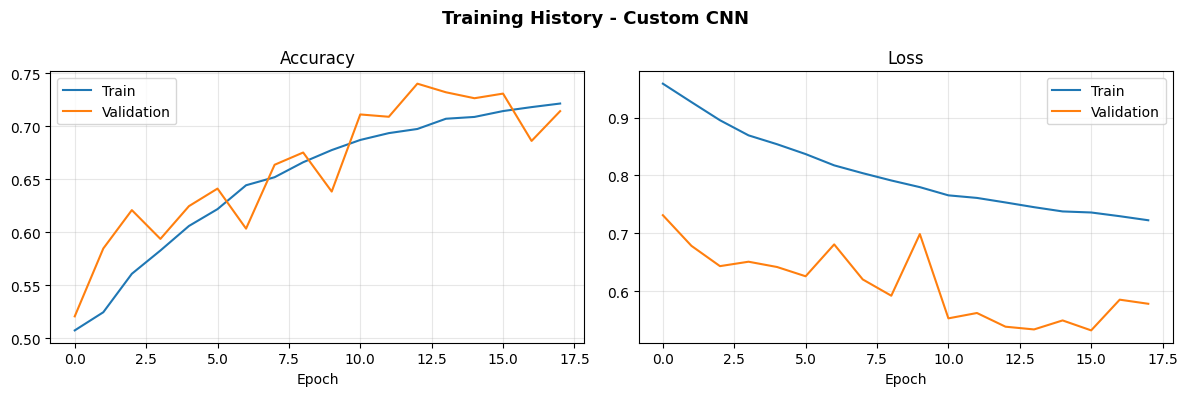

Custom CNN - Loss: 0.5384 | Accuracy: 0.7404


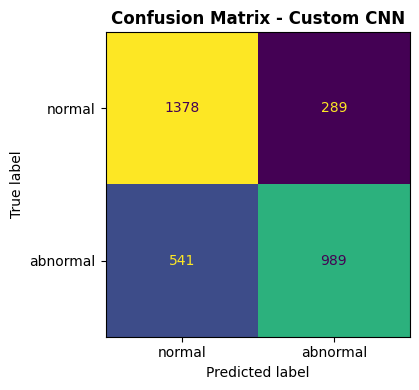

              precision    recall  f1-score   support

      normal       0.72      0.83      0.77      1667
    abnormal       0.77      0.65      0.70      1530

    accuracy                           0.74      3197
   macro avg       0.75      0.74      0.74      3197
weighted avg       0.74      0.74      0.74      3197



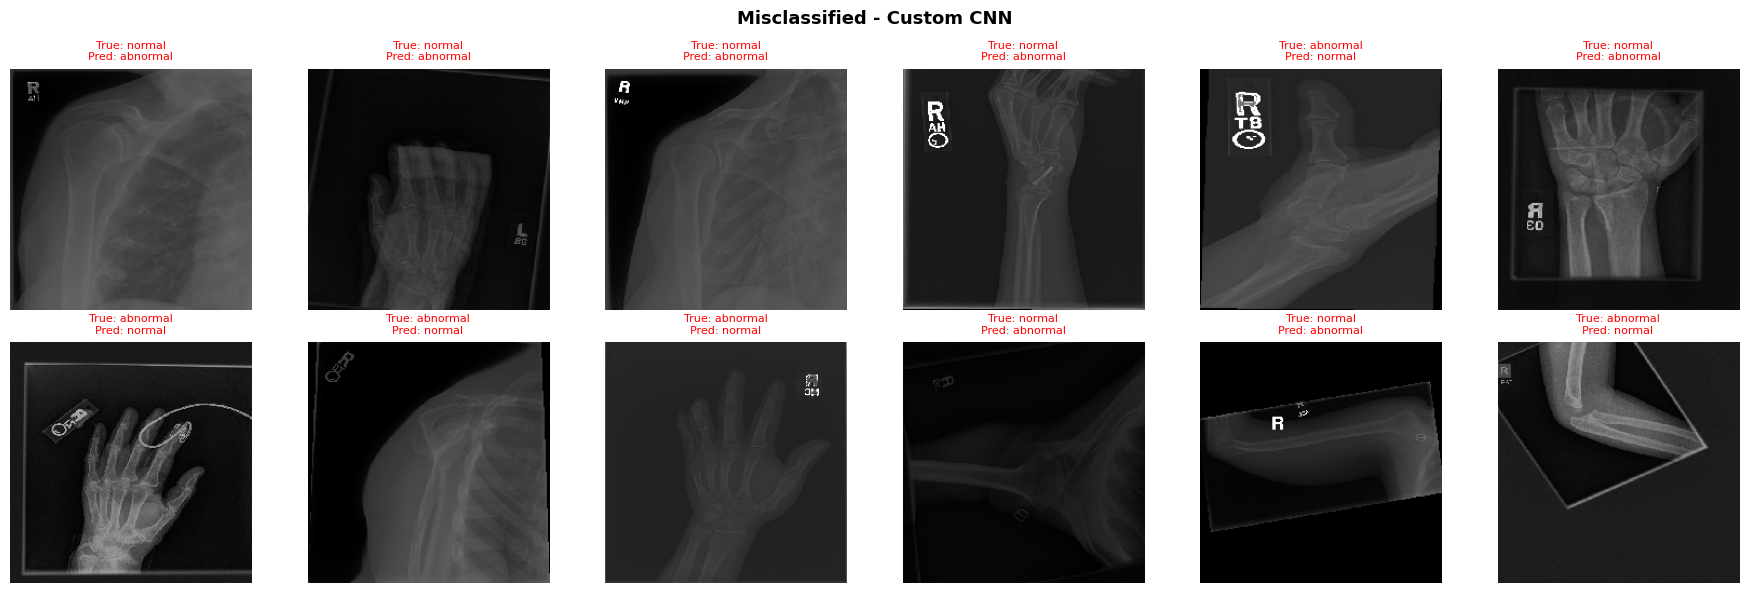

Total wrong: 830 / 3197
Logged: Custom CNN


/tmp/ipykernel_55/3404868902.py:36: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)


,model,val_loss,val_accuracy,precision_normal,recall_normal,f1_normal,precision_abnormal,recall_abnormal,f1_abnormal,epochs_trained
0,Custom CNN,0.5384,0.7404,0.7181,0.8266,0.7685,0.7739,0.6464,0.7044,18


In [12]:
es         = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
rlr        = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
checkpoint = ModelCheckpoint('/kaggle/working/cnn_best.keras', monitor='val_accuracy',
                              save_best_only=True, verbose=1)

cnn_history = cnn_model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=[es, rlr, checkpoint],
    class_weight=class_weight, verbose=1
)

plot_history(cnn_history, model_name='Custom CNN')
cnn_eval = evaluate(cnn_model, val_gen, model_name='Custom CNN')
plot_confusion_matrix(cnn_model, val_gen, model_name='Custom CNN')
show_misclassified(cnn_model, val_gen, model_name='Custom CNN')
log_results(cnn_model, val_gen, model_name='Custom CNN', history=cnn_history)

---
## Model 2 - DenseNet121 (Transfer Learning)

Instead of training from scratch, we reuse a network already trained on **ImageNet** (1.2M natural images). The model already knows how to detect edges, textures, and shapes — we just fine-tune it for X-rays.

**Why DenseNet121?** Stanford used it in their original MURA paper. It connects every layer to every previous layer (dense connections), giving excellent gradient flow and strong results on medical images.

### Two-phase training

**Phase 1 - Freeze the base, train only our new head (5 epochs)**  
This warms up the head without touching the ImageNet weights.

**Phase 2 - Unfreeze everything, fine-tune with lr=1e-5**  
The tiny learning rate gently adjusts all weights without destroying what was learned on ImageNet.

In [23]:
# DenseNet requires its own pixel normalisation - NOT a simple /255
dn_train_datagen = ImageDataGenerator(
    preprocessing_function=densenet_preprocess,
    horizontal_flip=True, rotation_range=15, zoom_range=0.1,
    width_shift_range=0.1, height_shift_range=0.1
)
dn_val_datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess)

dn_train_gen = dn_train_datagen.flow_from_dataframe(
    df_train, x_col='image_path', y_col='label_type',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', classes=['normal', 'abnormal'], shuffle=True, seed=42
)
dn_val_gen = dn_val_datagen.flow_from_dataframe(
    df_valid, x_col='image_path', y_col='label_type',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', classes=['normal', 'abnormal'], shuffle=False
)

Found 36808 validated image filenames belonging to 2 classes.
Found 3197 validated image filenames belonging to 2 classes.


### Phase 1 - Train the Classification Head

We load DenseNet121 with ImageNet weights and **freeze** all its layers. Only our new Dense head is trainable. This prevents the pre-trained features from being destroyed before the head learns useful weights.

In [25]:
dn_base  = DenseNet121(include_top=False, weights='imagenet',
                       input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
x        = Dense(256, activation='relu')(dn_base.output)
x        = Dropout(0.4)(x)
dn_out   = Dense(1, activation='sigmoid')(x)
dn_model = Model(inputs=dn_base.input, outputs=dn_out)

# Phase 1: freeze the base - only the head trains
for layer in dn_base.layers:
    layer.trainable = False

dn_model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)

print('Phase 1: training the head (base frozen) ...')
dn_p1 = dn_model.fit(
    dn_train_gen, validation_data=dn_val_gen,
    epochs=5, callbacks=[es], class_weight=class_weight, verbose=1,
    
)
print(f'Phase 1 done ({len(dn_p1.history["loss"])} epochs)')

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1: training the head (base frozen) ...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
576/576 ━━━━━━━━━━━━━━━━━━━━ 643s 1s/step - accuracy: 0.6040 - loss: 0.8979 - val_accuracy: 0.7069 - val_loss: 0.5596
Epoch 2/5
576/576 ━━━━━━━━━━━━━━━━━━━━ 571s 990ms/step - accuracy: 0.6732 - loss: 0.7859 - val_accuracy: 0.6994 - val_loss: 0.5620
Epoch 3/5
576/576 ━━━━━━━━━━━━━━━━━━━━ 561s 974ms/step - accuracy: 0.6886 - loss: 0.7719 - val_accuracy: 0.6978 - val_loss: 0.5615
Epoch 4/5
576/576 ━━━━━━━━━━━━━━━━━━━━ 556s 965ms/step - accuracy: 0.6928 - loss: 0.7588 - val_accuracy: 0.7332 - val_loss: 0.5317
Epoch 5/5
576/576 ━━━━━━━━━━━━━━━━━━━━ 559s 970ms/step - accuracy: 0.7047 - loss: 0.7530 - val_accuracy: 0.7119 - val_loss: 0.5468
Restoring model weights from the end of the best epoch: 4.
Phase 1 done (5 epochs)


### Phase 2 - Fine-Tune the Full Network

Now we **unfreeze** all layers and train the entire model with a very small learning rate (3e-5). This gently adjusts the pre-trained weights to better fit X-ray images without forgetting what as learned on ImageNet.

Phase 2: fine-tuning the full network ...
Epoch 1/30
206/576 ━━━━━━━━━━━━━━━━━━━━ 6:22 1s/step - accuracy: 0.6568 - loss: 0.8359

2026-03-11 11:46:55.341369: E external/local_xla/xla/service/slow_operation_alarm.cc:73] 
********************************
[Compiling module a_inference_one_step_on_data_355598__.68342] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2026-03-11 11:46:56.380868: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 2m1.03971037s

********************************
[Compiling module a_inference_one_step_on_data_355598__.68342] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6881 - loss: 0.7888
Epoch 1: val_accuracy improved from -inf to 0.77354, saving model to /kaggle/working/densenet_best.keras
576/576 ━━━━━━━━━━━━━━━━━━━━ 1125s 2s/step - accuracy: 0.6881 - loss: 0.7887 - val_accuracy: 0.7735 - val_loss: 0.4935 - learning_rate: 3.0000e-05
Epoch 2/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - accuracy: 0.7724 - loss: 0.6542
Epoch 2: val_accuracy did not improve from 0.77354
576/576 ━━━━━━━━━━━━━━━━━━━━ 579s 1s/step - accuracy: 0.7724 - loss: 0.6542 - val_accuracy: 0.7723 - val_loss: 0.4901 - learning_rate: 3.0000e-05
Epoch 3/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 956ms/step - accuracy: 0.7926 - loss: 0.6082
Epoch 3: val_accuracy improved from 0.77354 to 0.78355, saving model to /kaggle/working/densenet_best.keras
576/576 ━━━━━━━━━━━━━━━━━━━━ 571s 991ms/step - accuracy: 0.7926 - loss: 0.6082 - val_accuracy: 0.7835 - val_loss: 0.4757 - learning_rate: 3.0000e-05
Epoch 4/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 9

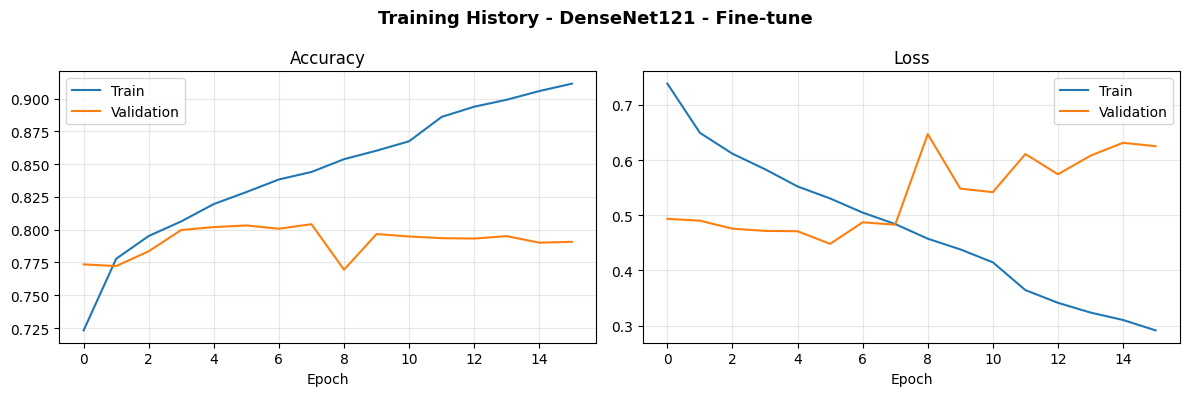

DenseNet121 - Loss: 0.4829 | Accuracy: 0.8042


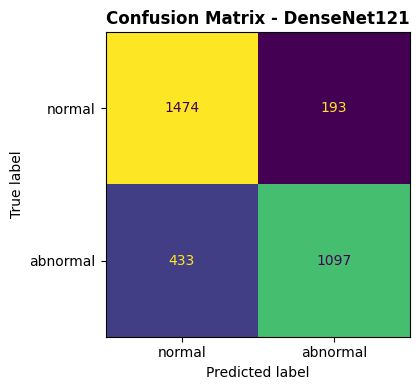

              precision    recall  f1-score   support

      normal       0.77      0.88      0.82      1667
    abnormal       0.85      0.72      0.78      1530

    accuracy                           0.80      3197
   macro avg       0.81      0.80      0.80      3197
weighted avg       0.81      0.80      0.80      3197



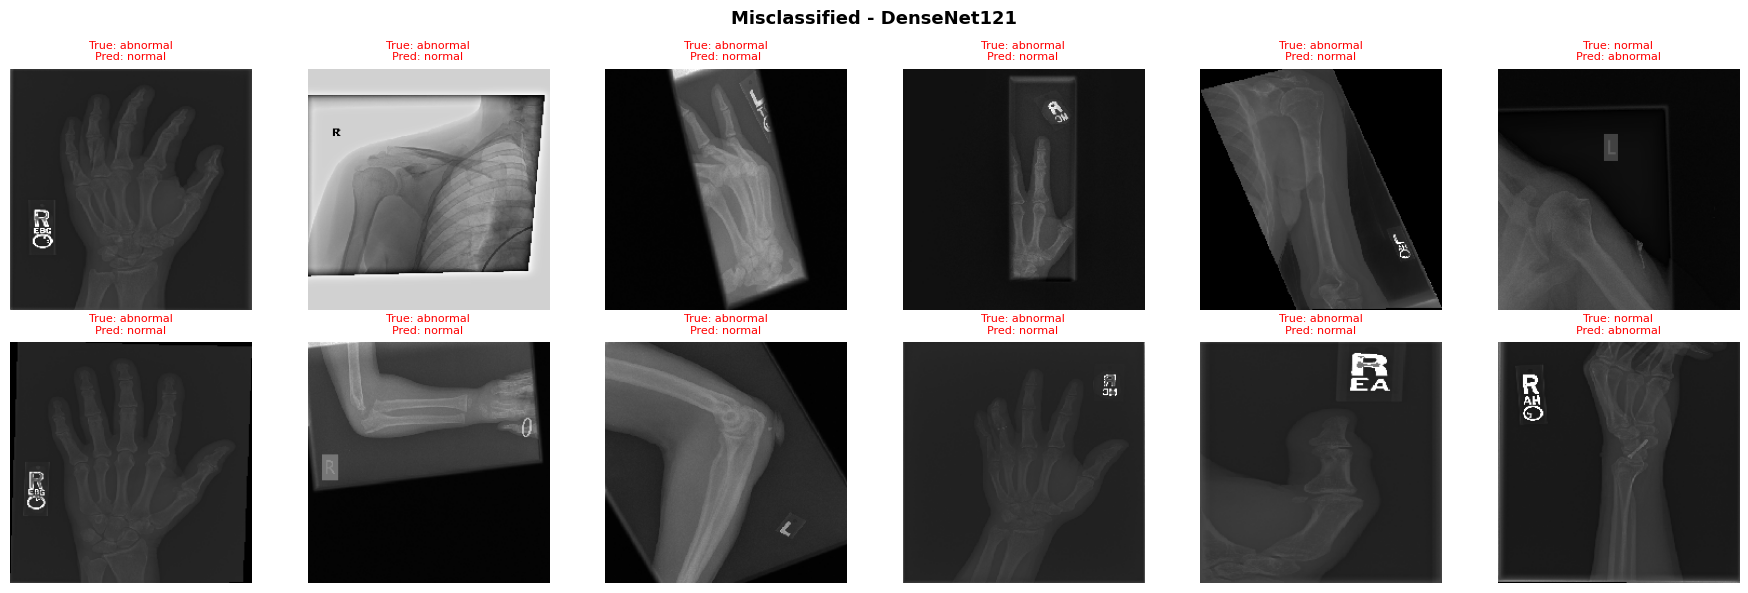

Total wrong: 626 / 3197
Logged: DenseNet121


,model,val_loss,val_accuracy,precision_normal,recall_normal,f1_normal,precision_abnormal,recall_abnormal,f1_abnormal,epochs_trained
0,Custom CNN,0.5384,0.7404,0.7181,0.8266,0.7685,0.7739,0.6464,0.7044,18
1,Custom CNN,0.5384,0.7404,0.7181,0.8266,0.7685,0.7739,0.6464,0.7044,18
2,DenseNet121,0.4829,0.8042,0.7729,0.8842,0.8248,0.8504,0.7170,0.7780,16


In [26]:
# Phase 2: unfreeze everything and fine-tune with a tiny learning rate
for layer in dn_base.layers:
    layer.trainable = True

dn_model.compile(optimizer=Adam(3e-5), loss='binary_crossentropy', metrics=['accuracy'])
es         = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)
rlr        = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint('/kaggle/working/densenet_best.keras', monitor='val_accuracy',
                              save_best_only=True, verbose=1)

print('Phase 2: fine-tuning the full network ...')
dn_p2 = dn_model.fit(
    dn_train_gen, validation_data=dn_val_gen,   # same generator as Phase 1 (full augmentation)
    epochs=EPOCHS, callbacks=[es, rlr, checkpoint], class_weight=class_weight, verbose=1
)
print(f'Phase 2 done ({len(dn_p2.history["loss"])} epochs)')

plot_history(dn_p2, model_name='DenseNet121 - Fine-tune')
dn_eval = evaluate(dn_model, dn_val_gen, model_name='DenseNet121')
plot_confusion_matrix(dn_model, dn_val_gen, model_name='DenseNet121')
show_misclassified(dn_model, dn_val_gen, model_name='DenseNet121')
log_results(dn_model, dn_val_gen, model_name='DenseNet121', history=dn_p2)

## Results Summary

Side-by-side comparison of both models on the validtion set

In [31]:
display(results_df)

,model,val_loss,val_accuracy,precision_normal,recall_normal,f1_normal,precision_abnormal,recall_abnormal,f1_abnormal,epochs_trained
0,Custom CNN,0.5384,0.7404,0.7181,0.8266,0.7685,0.7739,0.6464,0.7044,18
1,DenseNet121,0.4829,0.8042,0.7729,0.8842,0.8248,0.8504,0.7170,0.7780,16
